In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir('/home/jovyan/signal-extraction')

# Slide 1

In [2]:
!pip install dataretrieval
import dataretrieval.nwis as nwis

  Using cached dataretrieval-1.1.0-py3-none-any.whl.metadata (12 kB)
Using cached dataretrieval-1.1.0-py3-none-any.whl (60 kB)


In [3]:
# Input file information
time_var = 'datetime'  # Time variable name in source file for time series data
var_interest = 'discharge_cfs'
site = '11446500' #Site Number: American river at Fair Oaks
parameter_code = '00060' # Discharge (cfs)
start_date = "1904-10-01" # Beginning of record
end_date = "2025-12-01"

sig_start = '1904-10-01'
sig_end = "2025-06-01"

# Naming and formatting
data_type = "Streamflow" # Variable name in time series
data_unit = "cfs" # Variable unit in time series

In [309]:
#Download data 
df = nwis.get_record(sites = site, service = 'dv', start = start_date, end= end_date, parameterCd = parameter_code)
df[var_interest] = df[parameter_code+'_Mean']

# Ensure df index is also timezone-naive
df.index = df.index.tz_localize(None)

# Clip to the SAME date range as signal (inclusive)
df = df.loc[sig_start:sig_end]

# Resample to annual frequency and take the maximum daily
annual_max = df[var_interest].resample('YE').max()
annual_mean = df[var_interest].resample('YE').mean()
annual_sum = df[var_interest].resample('YE').sum()
# Extract the year from each date
years = df.index.year

# Find the unique years
time = np.unique(years)

# Convert the series to a DataFrame
annual_max_df = annual_max.to_frame(name='annual_max_streamflow')

# Identify annual maxima
time_series = annual_max_df['annual_max_streamflow'].values

In [5]:
import math

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle


def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

    return fig

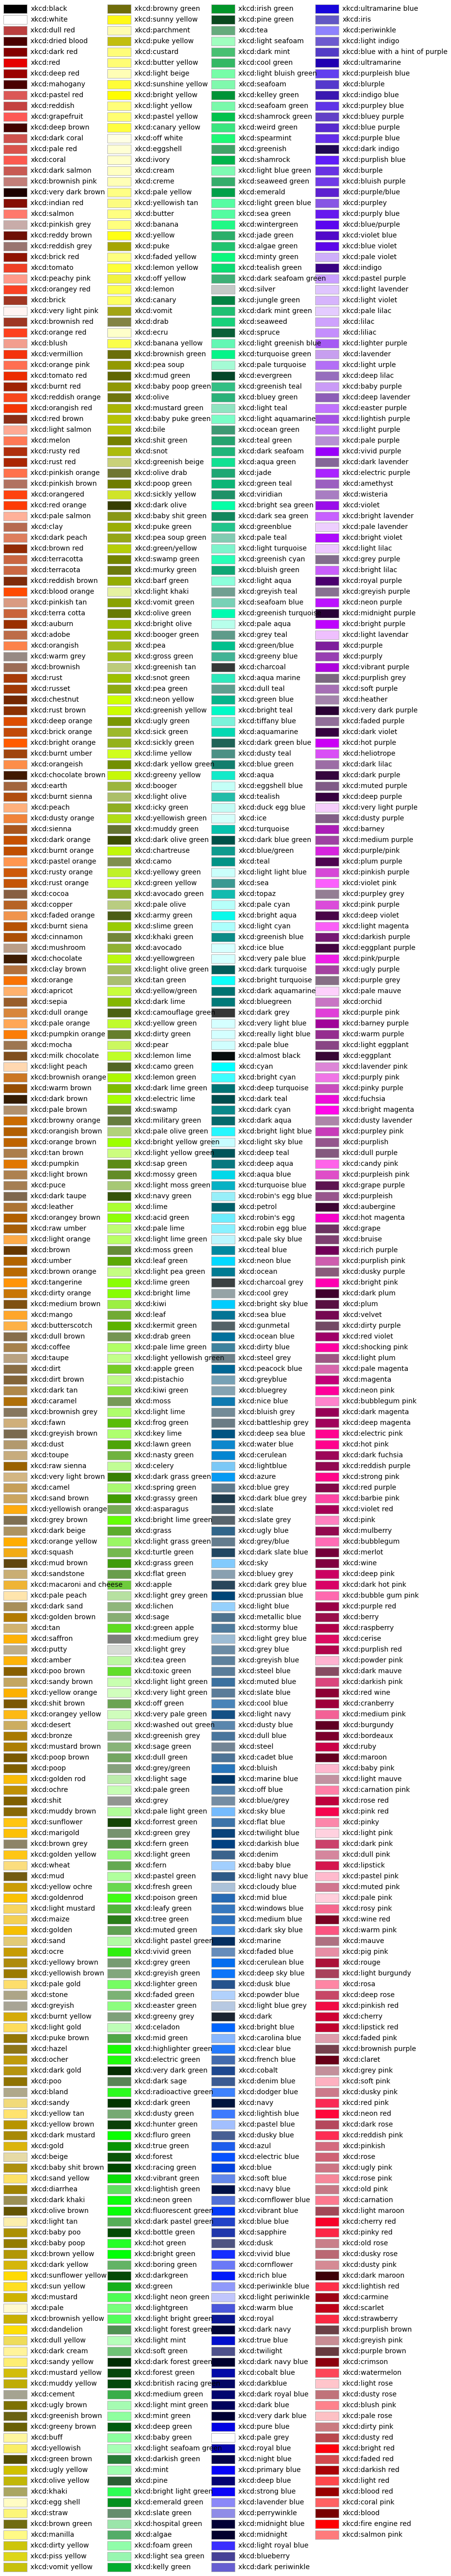

In [27]:
xkcd_fig = plot_colortable(mcolors.XKCD_COLORS)

In [6]:
plt.rcParams['font.size'] = 13          # base font size
plt.rcParams['axes.titlesize'] = 14     # title font size
plt.rcParams['axes.labelsize'] = 12     # x/y label size
plt.rcParams['xtick.labelsize'] = 10    # x tick labels
plt.rcParams['ytick.labelsize'] = 10    # y tick labels
plt.rcParams['legend.fontsize'] = 12    # legend
plt.rcParams['figure.titlesize'] = 14

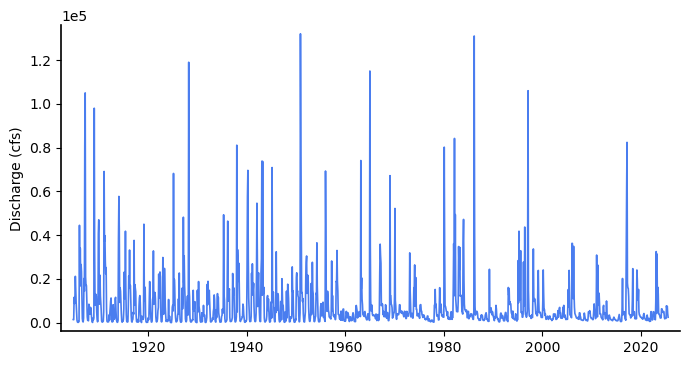

In [5]:
window = 1
log_scale = False 
ts = annual_max_df['annual_max_streamflow']
axis_width = 1.2

plt.rcParams['font.family'] = 'DejaVu Sans'

smoothed = ts.rolling(window, min_periods=1, center=True).mean()

#cerulean blue

plt.figure(figsize=(7,3.75))
ax = plt.gca()
plt.plot(smoothed, linewidth=1.2, color = 'xkcd:azul', alpha = 0.8, label=f"{window}-Year Mean Discharge (cfs)")
if log_scale: plt.yscale("log")

ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

ax.margins(x= 0.02, y= 0.03)
ax.set_ylabel("Discharge (cfs)")

# Remove bounding box spines
ax.spines["bottom"].set_linewidth(axis_width)
ax.spines["left"].set_linewidth(axis_width)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#plt.legend();
plt.tight_layout();
plt.show()

# Slide 2

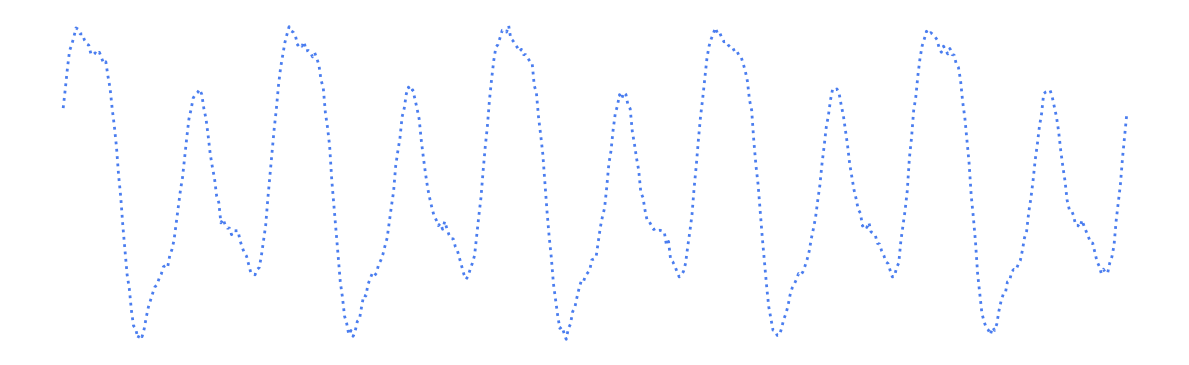

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create synthetic multiperiod oscillatory data
np.random.seed(42)

n = 500
x = np.linspace(0, 20*np.pi, n)

# Mix of multiple frequencies + gentle random drift
y = (
    0.8*np.sin(x) +
    0.4*np.sin(0.5*x + 1.3) +
    0.2*np.sin(2.5*x + 0.7) +
    0.1*np.random.normal(0, 0.2, n)
)

# Smooth the oscillatory curve (similar to rolling mean)
window = 1
y_smooth = pd.Series(y).rolling(window, center=True, min_periods=1).mean()

# Plot in your preferred style
plt.figure(figsize=(12, 3.75))
plt.rcParams['font.family'] = 'DejaVu Sans'

ax = plt.gca()
plt.plot(
    y_smooth,
    linewidth=2,
    color='xkcd:azul',
    alpha=0.8,
    ls=':',
    label='Synthetic Oscillatory Signal'
)

ax.set_axis_off()   # remove all axes/ticks/borders

plt.tight_layout()
plt.show()


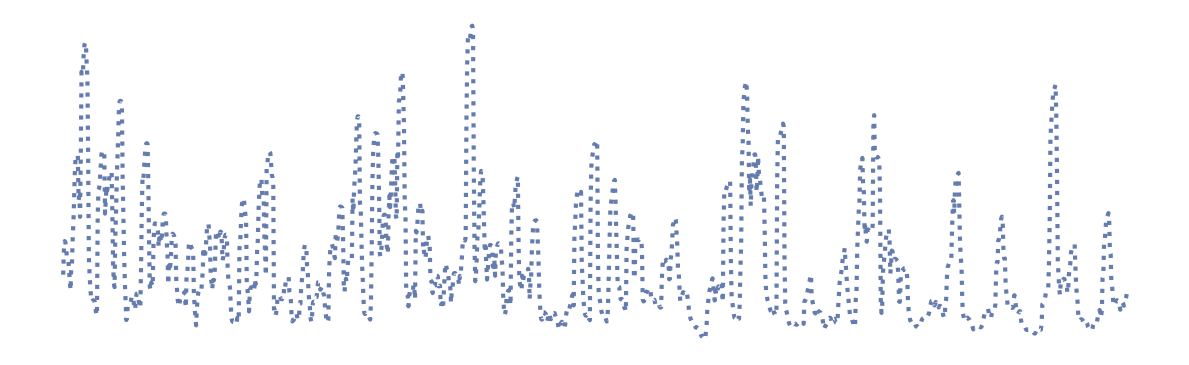

In [7]:
window = 10
log_scale = False 
ts = annual_max_df['annual_max_streamflow']
axis_width = 2

plt.rcParams['font.family'] = 'DejaVu Sans'

smoothed = ts.rolling(window, min_periods=1, center=True).mean()

#cerulean blue

plt.figure(figsize=(12,3.75))
ax = plt.gca()
plt.plot(smoothed, linewidth=3, color = '#3f5b9a', alpha = 0.8, ls=':', label=f"{window}-Year Mean Discharge (cfs)")
if log_scale: plt.yscale("log")

ax.set_axis_off()

#plt.legend();
plt.tight_layout();
plt.show()

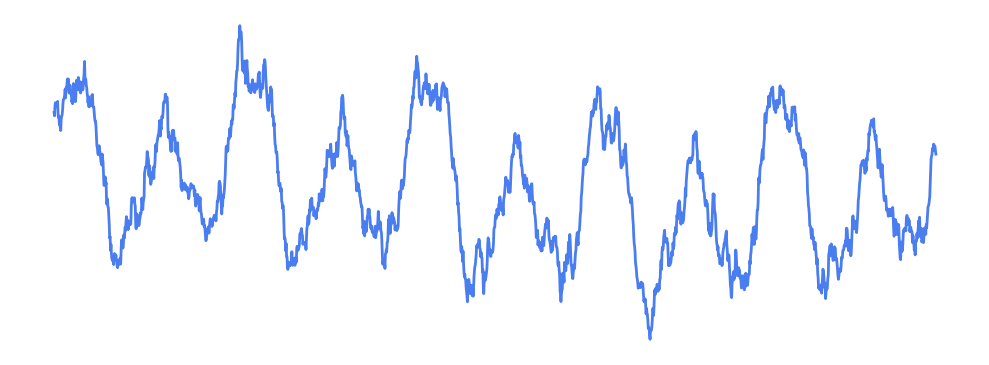

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create synthetic multiperiod oscillatory data
np.random.seed(42)

n = 2000
x = np.linspace(0, 20*np.pi, n)

# Base multiperiod oscillations
y = (
    0.4*np.sin(x) +
    0.2*np.sin(0.5*x + 1) +
    0.1*np.sin(2.5*x + 0.45)
)

# Add more noise: both high-frequency and low-frequency
noise_high = 0.25 * np.random.normal(0, 1, n)
noise_low  = 0.15 * np.sin(0.1*x + np.random.rand()*1)

y = y + noise_high + noise_low

# Smooth the series (similar to rolling mean)
window = 10
y_smooth = pd.Series(y).rolling(window, center=True, min_periods=1).mean()

# Plot in your preferred style
plt.figure(figsize=(10, 3.75))
plt.rcParams['font.family'] = 'DejaVu Sans'

ax = plt.gca()
plt.plot(
    y_smooth,
    linewidth=2,
    color='xkcd:azul',
    alpha=0.8,
    ls='-',   # dotted style
)

ax.set_axis_off()   # remove all axes/ticks/spines

plt.tight_layout()
plt.show()


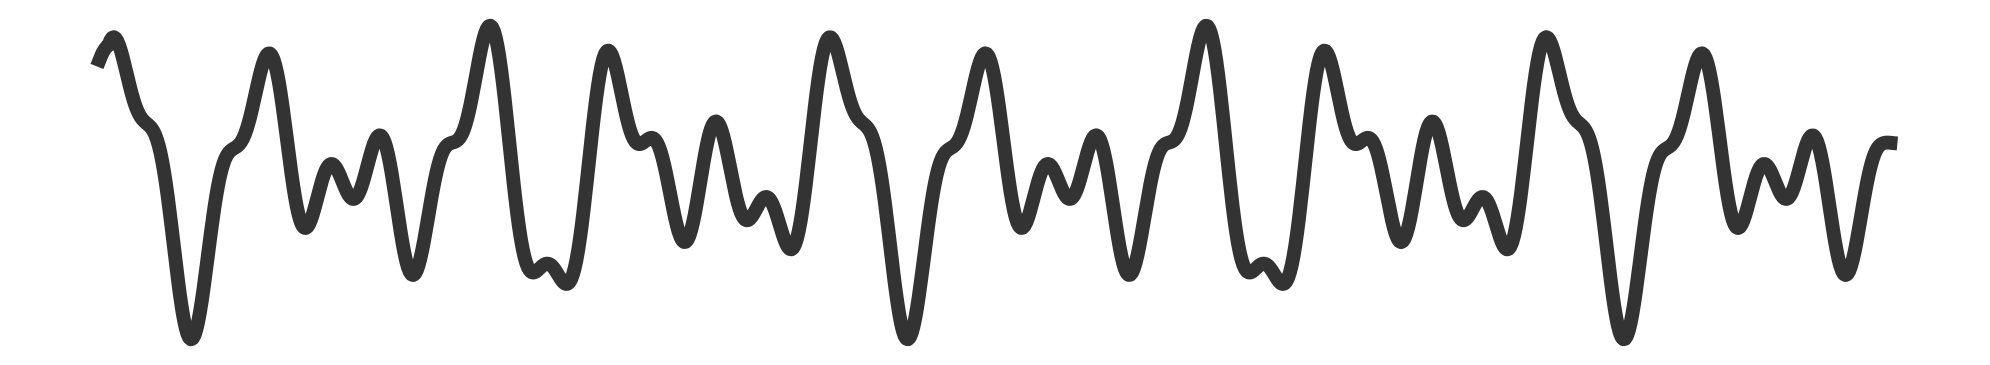

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

# Keep same length as before (500 points)
n = 1000
x = np.linspace(0, 20*np.pi, n)

# Increase frequencies for more peaks
y = (
    0.5*np.sin(1.5 * x) +           # doubled frequency
    0.4*np.sin(1.0 * x + 1.3) +     # higher-frequency component
    0.3*np.sin(3.25 * x + 0.7)       # NEW high-frequency oscillations
)

# Add noise
#noise_high = 0.25 * np.random.normal(0, 1, n)
#noise_low  = 0.15 * np.sin(0.1*x + np.random.rand()*5)

#y = y + noise_high + noise_low

# Smooth
window = 10
y_smooth = pd.Series(y).rolling(window, center=True, min_periods=1).mean()

# Plot in your style
plt.figure(figsize=(20, 3.75))
plt.rcParams['font.family'] = 'DejaVu Sans'

ax = plt.gca()
plt.plot(
    y_smooth,
    linewidth=10,
    color='black',
    alpha=0.8,
    ls='-'    # dotted line
)

ax.set_axis_off()  # remove axes completely

plt.tight_layout()
plt.show()


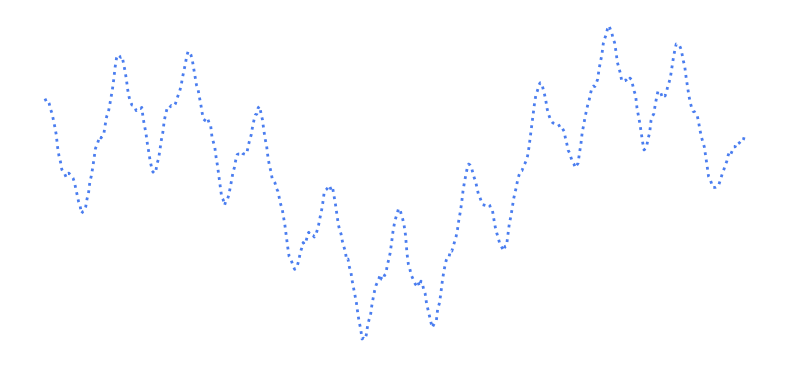

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

n = 500
x = np.linspace(0, 20*np.pi, n)

# Exaggerated low-frequency oscillation (BIG, slow swings)
low_freq = 1.0 * np.sin(0.15 * x)     # <-- amplitude up, frequency down

# Higher-frequency texture
mid_freq = 0.6 * np.sin(1.0 * x + 1.3)
high_freq = 0.3 * np.sin(3.0 * x + 0.7)

# Combine components
y = low_freq + mid_freq + high_freq

# Add noise
noise_high = 0.2 * np.random.normal(0, 1, n)
noise_low  = 0.15 * np.sin(0.08*x + np.random.rand()*5)

y = y + noise_high + noise_low

# Smooth
window = 10
y_smooth = pd.Series(y).rolling(window, center=True, min_periods=1).mean()

# Plot
plt.figure(figsize=(8, 3.75))
plt.rcParams['font.family'] = 'DejaVu Sans'

ax = plt.gca()
plt.plot(
    y_smooth,
    linewidth=2,
    color='xkcd:azul',
    alpha=0.8,
    ls=':'
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

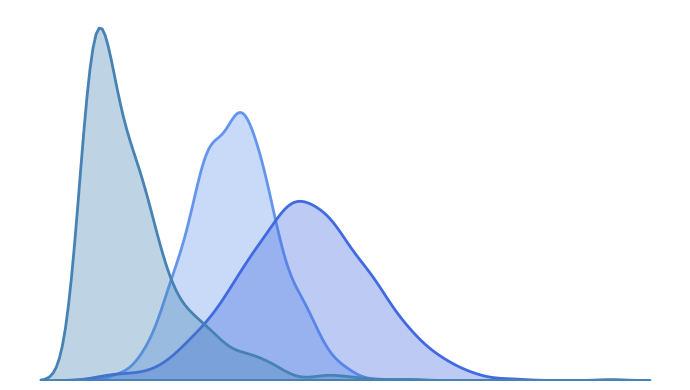

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gamma

# --- Example data ---
np.random.seed(42)

# Normal distributions
dist1 = np.random.normal(loc=3.5, scale=1, size=1000)
dist2 = np.random.normal(loc=5, scale=1.5, size=1000)

# Gamma distribution (shape k, scale θ)
dist3 = gamma(a=1.2, scale=1.0).rvs(1000)   # shifted right for separation

plt.figure(figsize=(7,4))

sns.kdeplot(dist1, fill=True, alpha=0.35, linewidth=2, color="cornflowerblue", label="Normal 1")
sns.kdeplot(dist2, fill=True, alpha=0.35, linewidth=2, color="royalblue", label="Normal 2")
sns.kdeplot(dist3, fill=True, alpha=0.35, linewidth=2, color="steelblue", label="Gamma")

ax = plt.gca()
ax.set_axis_off()

plt.tight_layout()
plt.show()


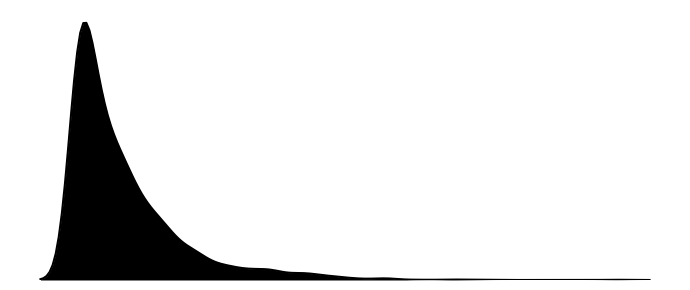

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Generate gamma-distributed samples
np.random.seed(42)
dist = gamma(a=0.75, scale=2).rvs(3000)

plt.figure(figsize=(7,3))

# Filled region with your exact color
sns.kdeplot(
    dist,
    fill=True,
    color="black",   # your fill color
    alpha=1.0,
    linewidth=0          # remove outline for the fill
)

# Black outline on top
sns.kdeplot(
    dist,
    fill=False,
    color="black",
    linewidth=1.5
)

# Remove all axes, ticks, spines
ax = plt.gca()
ax.set_axis_off()

plt.tight_layout()
plt.show()


import matplotlib.font_manager as fm
sorted(set(f.name for f in fm.fontManager.ttflist))

plt.rcParams.keys()

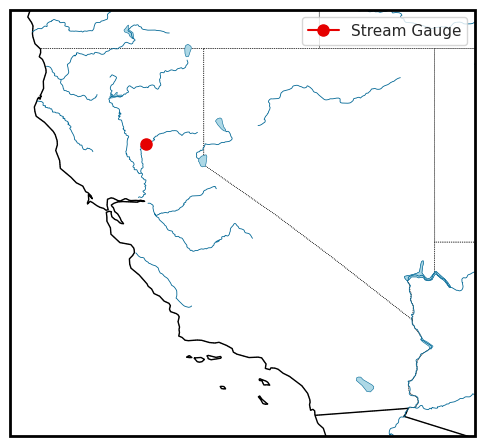

In [429]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# --- replace these with your actual coords ---
gauge_lat = 39.538
gauge_lon = -121.494

plt.figure(figsize=(6, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

# Add natural earth boundaries
ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5, linestyle=":")
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax.add_feature(cfeature.BORDERS.with_scale('50m'))

# --- ADD LAKES ---
ax.add_feature(cfeature.LAKES.with_scale('50m'),
               facecolor='lightblue', edgecolor='xkcd:peacock blue', linewidth=0.4)

# --- ADD HIGH-RES RIVERS ---
rivers_10m = cfeature.NaturalEarthFeature(
    'physical', 'rivers_lake_centerlines', '10m',
    edgecolor='xkcd:peacock blue', facecolor='none'
)
ax.add_feature(rivers_10m, linewidth=0.6)


# Set extent around California
ax.set_extent([-125, -113, 32, 43], crs=ccrs.PlateCarree())

# Plot gauge location
ax.plot(
    gauge_lon,
    gauge_lat,
    marker='o',
    markersize=8,
    color='xkcd:red',
    transform=ccrs.PlateCarree(),
    label="Stream Gauge"
)

for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor("black")

plt.legend()
#plt.title("Stream Gauge Location in California")
plt.show()


# Results Time Series Plot

In [13]:
import xarray as xr
import pandas as pd
import numpy as np

def test_dates(
        path_to_input_netcdf: str,
        train_pct: float,
        sst_recon,          # xr.DataArray or xr.Dataset
        precip_recon,       # xr.DataArray or xr.Dataset
        latent_df: pd.DataFrame   # already loaded DataFrame
    ):
    """
    Assign correct test-period timestamps to SST, precipitation, and latent outputs
    using a single source NetCDF dataset for the time coordinate.
    Automatically REPLACES their time coordinates / indices.

    Parameters
    ----------
    path_to_input_netcdf : str
        The dataset used during training (single source of truth for time).
    train_pct : float
        Fraction of dataset used for training (e.g., 0.7).
    sst_recon, precip_recon :
        Xarray objects holding ONLY test-period reconstructions.
    latent_df : pd.DataFrame
        Already loaded DataFrame containing latent test reconstruction.

    Returns
    -------
    dict with:
        {
            "test_time",
            "train_len",
            "sst_recon",
            "precip_recon",
            "latent_recon"
        }
    """

    # -------------------------------------
    # Load input dataset and extract time
    # -------------------------------------
    ds = xr.open_dataset(path_to_input_netcdf)

    time = None
    for key in ["time", "valid_time"]:
        if key in ds.coords:
            time = ds[key].values
            break

    if time is None:
        raise ValueError("Input dataset has no 'time' or 'valid_time' coordinate.")

    # Normalize dtype
    time = pd.to_datetime(time)

    # -------------------------------------
    # Compute train_len
    # -------------------------------------
    total_len = len(time)
    train_len = int(np.floor(train_pct * total_len))

    if train_len <= 0 or train_len >= total_len:
        raise ValueError(
            f"train_pct={train_pct} -> train_len={train_len} invalid for total_len={total_len}."
        )

    # -------------------------------------
    # Define test time axis
    # -------------------------------------
    test_time = time[train_len:]
    test_len = len(test_time)

    # -------------------------------------
    # Replace SST reconstruction time coords
    # -------------------------------------
    if "time" not in sst_recon.dims:
        raise ValueError("sst_recon must have a 'time' dimension.")

    if len(sst_recon.time) != test_len:
        print(f"WARNING: SST length {len(sst_recon.time)} != test_len {test_len}")

    sst_recon = sst_recon.assign_coords(time=test_time)

    # -------------------------------------
    # Replace Precip reconstruction time coords
    # -------------------------------------
    if "time" not in precip_recon.dims:
        raise ValueError("precip_recon must have a 'time' dimension.")

    if len(precip_recon.time) != test_len:
        print(f"WARNING: Precip length {len(precip_recon.time)} != test_len {test_len}")

    precip_recon = precip_recon.assign_coords(time=test_time)

    # -------------------------------------
    # Replace LATENT DataFrame index
    # -------------------------------------
    if latent_df.shape[0] != test_len:
        print(
            f"WARNING: latent_df rows={latent_df.shape[0]} do not match test_len={test_len}"
        )

    # Replace index with datetime
    latent_df = latent_df.copy()
    latent_df.index = test_time
    latent_df.index.name = "time"

    # -------------------------------------
    # Return updated outputs
    # -------------------------------------
    return {
        "test_time": test_time,
        "train_len": train_len,
        "sst_recon": sst_recon,
        "precip_recon": precip_recon,
        "latent_recon": latent_df,
    }


In [14]:
latent_recon = pd.read_csv('~/signal-extraction/results/gam_nll_final2/latent_test.csv')
sst_recon = xr.open_dataset('~/signal-extraction/results/gam_nll_final2/sst_recon_test.nc')
precip_recon = xr.open_dataset('~/signal-extraction/results/gam_nll_final2/sst_recon_test.nc')

results = test_dates(
    path_to_input_netcdf="~/signal-extraction/vae_input_data/tp_mon-sum.nc",
    train_pct=0.8,
    sst_recon=sst_recon,
    precip_recon=precip_recon,
    latent_df=latent_recon
)

sst_recon   = results["sst_recon"]
precip_recon = results["precip_recon"]
latent_df    = results["latent_recon"]

In [16]:
print(latent_df)

                     time     alpha       beta         z    lambda
time                                                              
2008-05-16 00:00:00     0  1.895327   3.030474  0.274296  0.625423
2008-06-15 12:00:00     1  2.025121   1.841644  0.933045  1.099627
2008-07-16 00:00:00     2  2.036211   1.897819  0.789537  1.072922
2008-08-16 00:00:00     3  2.023973   1.953892  0.205311  1.035867
2008-09-15 12:00:00     4  2.024936   1.856422  0.554039  1.090773
...                   ...       ...        ...       ...       ...
2025-02-14 12:00:00   201  1.341198  10.238646  0.449870  0.130994
2025-03-16 00:00:00   202  1.458541   9.489301  0.056724  0.153704
2025-04-15 12:00:00   203  1.839014   4.210519  0.159777  0.436767
2025-05-16 00:00:00   204  1.982564   2.489207  0.976231  0.796464
2025-06-15 12:00:00   205  2.038015   1.932245  1.562054  1.054740

[206 rows x 5 columns]


nino = pd.read_csv('~/signal-extraction/vae_input_data/psl_nino34_index_clean.csv')
pdo = pd.read_csv('~/signal-extraction/vae_input_data/ncei_pdo_index.csv')
#pna = pd.read_csv('~/signal-extraction/vae_input_data/ncep_pna_index.csv')

mimoae = pd.read_csv('~/signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv')
mimoae['time'] = pd.to_datetime(mimoae["time"]).dt.to_period("M").dt.to_timestamp()
mimoae['ae3'] = mimoae['latent'].rolling(window=3, center = True).mean()


nino = nino.rename(columns={'DATE':'time','INDEX' : 'nino'})
pdo = pdo.rename(columns={'Date':'time','value' : 'pdo'})
#pna = pna.rename(columns={'Date':'time','value' : 'pna'})

nino['nino3'] = nino['nino'].rolling(window=3, center = True).mean()
pdo['pdo3'] = pdo['pdo'].rolling(window=3, center = True).mean()
#pna['pna3'] = pna['pna'].rolling(window=3, center = True).mean()

#latent = pd.read_csv("~/signal-extraction/results/gam_nll_final2/latent_test.csv")
latent = latent_df
precip = pd.read_csv("~/signal-extraction/vae_input_data/GHCND_Sac_5ESE_monsum.csv")

latent = latent.drop(columns = ['alpha','beta','lambda'])

latent["time"] = pd.to_datetime(latent["time"]).dt.to_period("M").dt.to_timestamp()
precip['time'] = pd.to_datetime(precip["time"]).dt.to_period("M").dt.to_timestamp()

latent['3mol'] = latent["z"].rolling(window=3, center=True).mean()
precip['3mop'] = precip['PRCP'].rolling(window=3, center = True).mean()

In [83]:
# -------------------------
# Load your climate indices
# -------------------------
nino = pd.read_csv('~/signal-extraction/vae_input_data/psl_nino34_index_clean.csv')
pdo = pd.read_csv('~/signal-extraction/vae_input_data/ncei_pdo_index.csv')
mimoae = pd.read_csv('~/signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv')

nino = nino.rename(columns={'DATE':'time','INDEX':'nino'})
pdo = pdo.rename(columns={'Date':'time','value':'pdo'})

nino['time'] = pd.to_datetime(nino['time']).dt.to_period("M").dt.to_timestamp()
pdo['time']  = pd.to_datetime(pdo['time']).dt.to_period("M").dt.to_timestamp()

nino['nino3'] = nino['nino'].rolling(3, center=True).mean()
pdo['pdo3']  = pdo['pdo'].rolling(3, center=True).mean()

mimoae['time'] = pd.to_datetime(mimoae["time"]).dt.to_period("M").dt.to_timestamp()
mimoae['ae3']  = mimoae['latent'].rolling(window=3, center=True).mean()

# -------------------------
# Latent reconstruction
# -------------------------
latent = latent_df.copy()          # result from your assign_time function
latent = latent.drop(columns=['alpha','beta','lambda'], errors='ignore')

# Convert its index to monthly timestamps (consistent with others)
latent.index = latent.index.to_period("M").to_timestamp()
latent.index.name = "time"
latent["time"] = latent.index

latent['3mol'] = latent['z'].rolling(window=3, center=True).mean()
latent['3mon']= latent['3mol']*(-1)
# -------------------------
# Precip time series
# -------------------------
precip = pd.read_csv("~/signal-extraction/vae_input_data/GHCND_Sac_5ESE_monsum.csv")
precip['time'] = pd.to_datetime(precip["time"]).dt.to_period("M").dt.to_timestamp()
precip['3mop'] = precip['PRCP'].rolling(window=3, center=True).mean()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def timeplot_multi(series_list, labels=None, title="Multi-Series Comparison", target_index=None):
    """
    Plot multiple aligned time series from (df, seriescol) pairs.
    Compute Pearson correlation r between a target series and all others.

    series_list: list of (df, column_name)
    labels:      list of labels (optional)
    target_index: index of the reference series for r calculations
    """

    n = len(series_list)
    if labels is None:
        labels = [f"Series {i+1}" for i in range(n)]
    if len(labels) != n:
        raise ValueError("Length of labels must match length of series_list")

    aligned = None

    # -----------------------
    # STEP 1: Load and align time series
    # -----------------------
    for i, (df, scol) in enumerate(series_list):

        df = df.copy()
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df[scol] = pd.to_numeric(df[scol], errors="coerce")

        # Convert timestamps to month-start
        df["time_norm"] = df["time"].dt.to_period("M").dt.to_timestamp()

        df_i = df[["time_norm", scol]].rename(columns={scol: labels[i]})

        aligned = df_i if aligned is None else aligned.merge(df_i, on="time_norm", how="inner")

    aligned = aligned.dropna()

    if len(aligned) < 2:
        raise ValueError("Not enough overlapping timestamps across all series.")

    # -----------------------
    # STEP 2: Standardize for plotting
    # -----------------------
    time = aligned["time_norm"]
    standardized = {}

    for label in labels:
        x = aligned[label].astype(float).values
        standardized[label] = (x - x.mean()) / x.std()

    # -----------------------
    # STEP 3: Compute Pearson r if requested
    # -----------------------
    r_values = None

    if target_index is not None:
        if not (0 <= target_index < n):
            raise ValueError(f"target_index must be between 0 and {n-1}")

        target_label = labels[target_index]
        y = aligned[target_label].astype(float).values

        r_values = {}

        for i, label in enumerate(labels):
            if i == target_index:
                continue
            x = aligned[label].astype(float).values
            r, _ = pearsonr(y, x)
            r_values[label] = r

    # -----------------------
    # STEP 4: Plot all standardized series
    # -----------------------
    plt.figure(figsize=(14, 5))

    for i, label in enumerate(labels):
        if r_values and i != target_index:
            r_txt = f" (r={r_values[label]:.2f})"
        else:
            r_txt = ""

        plt.plot(time, standardized[label], label=label + r_txt, linewidth=1.2)

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Standardized Value")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def timeplot_multi2(series_list, labels=None, title="Multi-Series Comparison",
                   target_index=None):
    """
    Plot multiple aligned time series from (df, seriescol[, style_dict]) tuples.

    Each element in series_list may be either:
        (df, column_name)
    or:
        (df, column_name, style_dict)

    style_dict can include:
        'color', 'linewidth', 'linestyle', 'alpha', 'marker', etc.

    labels: list of legend labels (optional)
    target_index: index of reference series for computing Pearson r
    """

    # --------------------------------------
    # Parse series_list into components
    # --------------------------------------
    dfs = []
    cols = []
    styles = []

    for item in series_list:
        if len(item) == 2:
            df, col = item
            style = {}   # default style
        elif len(item) == 3:
            df, col, style = item
        else:
            raise ValueError("Each item in series_list must be (df, col) or (df, col, style).")

        dfs.append(df)
        cols.append(col)
        styles.append(style)

    n = len(dfs)

    # --------------------------------------
    # Handle labels
    # --------------------------------------
    if labels is None:
        labels = [f"Series {i+1}" for i in range(n)]
    if len(labels) != n:
        raise ValueError("Length of labels must match series_list.")

    # --------------------------------------
    # STEP 1 — Merge & align time series
    # --------------------------------------
    aligned = None

    for i in range(n):
        df = dfs[i].copy()
        scol = cols[i]

        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df[scol]   = pd.to_numeric(df[scol], errors="coerce")

        df["time_norm"] = df["time"].dt.to_period("M").dt.to_timestamp()
        df_i = df[["time_norm", scol]].rename(columns={scol: labels[i]})

        aligned = df_i if aligned is None else aligned.merge(df_i, on="time_norm", how="inner")

    aligned = aligned.dropna()
    if len(aligned) < 2:
        raise ValueError("Not enough overlapping timestamps across all series.")

    # --------------------------------------
    # STEP 2 — Standardize
    # --------------------------------------
    standardized = {}
    time = aligned["time_norm"]

    for label in labels:
        x = aligned[label].astype(float).values
        standardized[label] = (x - x.mean()) / x.std()

    # --------------------------------------
    # STEP 3 — Pearson correlations
    # --------------------------------------
    r_values = None

    if target_index is not None:
        target_label = labels[target_index]
        y = aligned[target_label].astype(float).values

        r_values = {}
        for i, label in enumerate(labels):
            if i == target_index:
                continue
            x = aligned[label].astype(float).values
            r, _ = pearsonr(y, x)
            r_values[label] = r

    # --------------------------------------
    # STEP 4 — Plotting
    # --------------------------------------
    plt.figure(figsize=(14, 5))

    for i, label in enumerate(labels):

        # Add correlation text
        if r_values and i != target_index:
            r_txt = f" (r={r_values[label]:.2f})"
        else:
            r_txt = ""

        # Pull style dict for this series
        style_kwargs = styles[i] if styles[i] else {}

        # Plot
        plt.plot(time, standardized[label], label=label + r_txt, **style_kwargs)

    plt.title(title)
    plt.legend()

    # Increase axis label and tick font sizes
    #plt.xlabel("Time", fontsize=14)
    plt.ylabel("Standardized Index", fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    # Remove top and right spines
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


In [178]:
plotlist =[
    (precip, "3mop", {"color":"#4285f4cc", "linewidth":2.0, "linestyle":"-",  "alpha":0.9}),
    (latent, "3mon", {"color":"black", "linewidth":2.0, "linestyle":"-",  "alpha":0.9}), 
    #(nino, 'nino3', {"color":"#fa7a4ddb", "linewidth":2.0, "linestyle":"-",  "alpha":0.9}),
    #(pdo, 'pdo3', {"color":"#C44E52", "linewidth":2.0, "linestyle":"-",  "alpha":0.9}),
    (mimoae, 'ae3', {"color":"seagreen", "linewidth":2.0, "linestyle":"-",  "alpha":0.9})
    ]

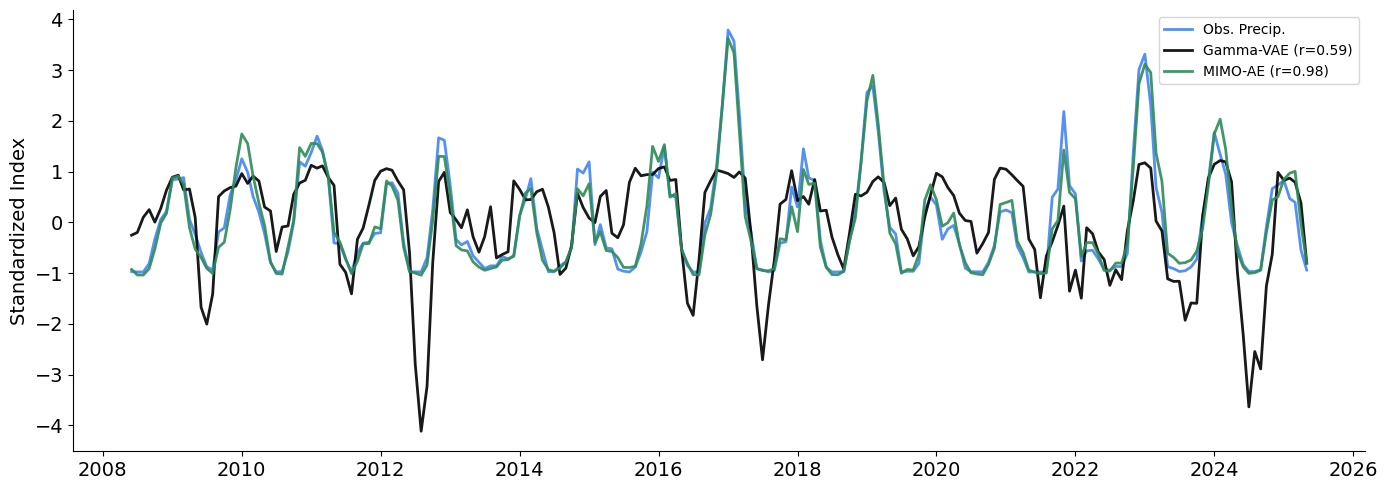

In [179]:
timeplot_multi2(plotlist, labels = ['Obs. Precip.','Gamma-VAE', 'MIMO-AE'], title = '', target_index=0)

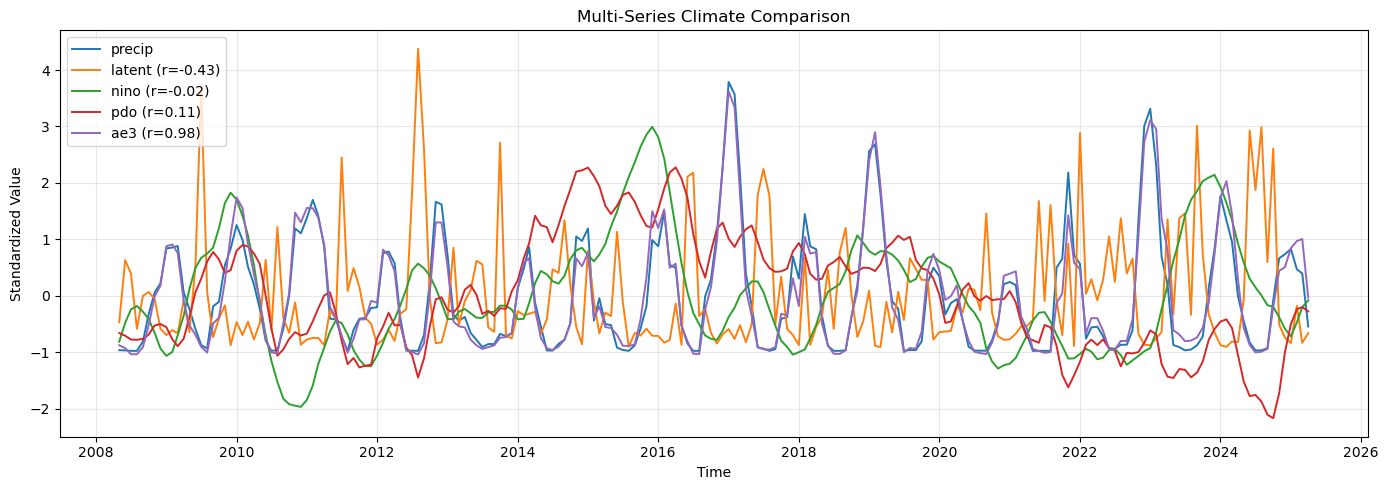

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ================================================================
# INPUT SECTION
# Replace these with your actual DataFrames and column names
# series_list = [(df, "colname"), ...]
# labels = ["precip", "latent", "nino", "pdo", "ae3"]
# Choose one index as correlation target, or set to None
# ================================================================

series_list = [
    (precip, "3mop"),
    (latent, "z"),
    (nino,   "nino3"),
    (pdo,    "pdo3"),
    (mimoae, "ae3")
]

labels = ["precip", "latent", "nino", "pdo", "ae3"]
target_index = 0      # compute correlations against precip
title = "Multi-Series Climate Comparison"

# ================================================================
# STEP 1: Align all time series on monthly timestamps
# ================================================================
aligned = None

for i, (df, scol) in enumerate(series_list):

    df = df.copy()

    # Use existing index if time column missing
    if "time" not in df.columns:
        df["time"] = df.index

    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df[scol] = pd.to_numeric(df[scol], errors="coerce")

    # Normalize timestamps to month-start
    df["time_norm"] = df["time"].dt.to_period("M").dt.to_timestamp()

    # Keep only time + selected series
    df_i = df[["time_norm", scol]].rename(columns={scol: labels[i]})

    aligned = df_i if aligned is None else aligned.merge(df_i, on="time_norm", how="inner")

# Drop non-overlapping rows
aligned = aligned.dropna()

if len(aligned) < 2:
    raise ValueError("Not enough overlapping timestamps across all series.")

# ================================================================
# STEP 2: Standardize each series for plotting (Z-score)
# ================================================================
standardized = {}
time = aligned["time_norm"]

for label in labels:
    x = aligned[label].astype(float).values
    standardized[label] = (x - x.mean()) / x.std()

# ================================================================
# STEP 3: Compute Pearson r values (optional)
# ================================================================
r_values = {}

if target_index is not None:
    target_label = labels[target_index]
    y = aligned[target_label].astype(float).values

    for i, label in enumerate(labels):
        if i == target_index:
            continue
        x = aligned[label].astype(float).values
        r, _ = pearsonr(y, x)
        r_values[label] = r

# ================================================================
# STEP 4: Plot
# ================================================================
plt.figure(figsize=(14, 5))

for i, label in enumerate(labels):

    if target_index is not None and i != target_index:
        r_txt = f" (r={r_values[label]:.2f})"
    else:
        r_txt = ""

    plt.plot(time, standardized[label], linewidth=1.4, label=label + r_txt)

plt.title(title)
plt.xlabel("Time")
plt.ylabel("Standardized Value")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# aligned now contains the merged, aligned raw series


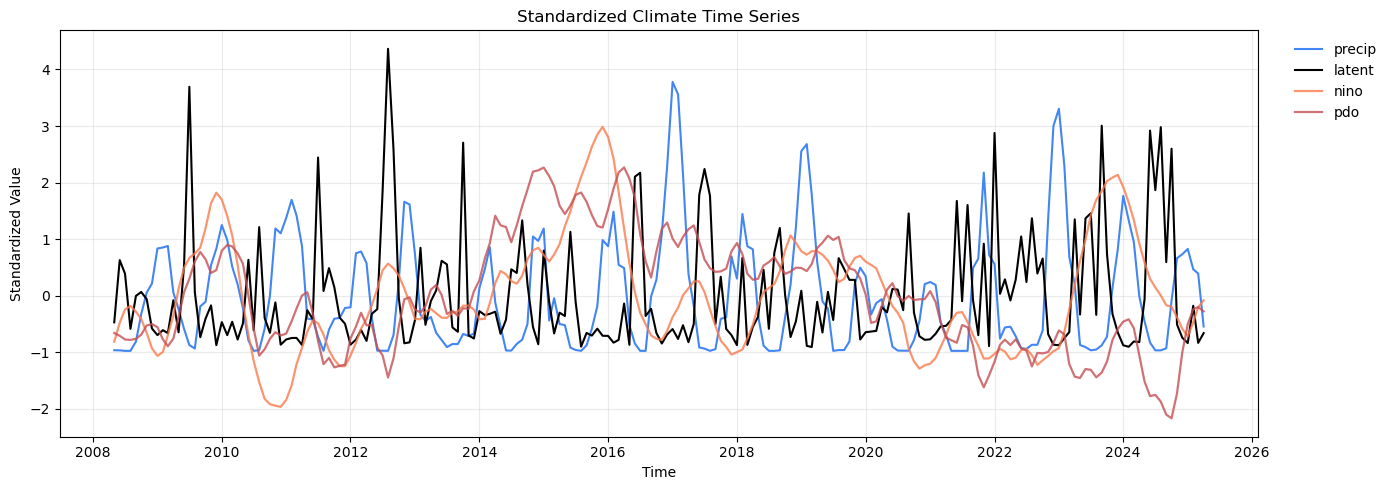

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# ============================
# 0. Prepare standardized data
# ============================
dfp = aligned.copy()   # use your aligned DataFrame

def z(x):
    return (x - x.mean()) / x.std()

# Create standardized versions
dfp["precip_z"] = z(dfp["precip"])
dfp["latent_z"] = z(dfp["latent"])
dfp["nino_z"]   = z(dfp["nino"])
dfp["pdo_z"]    = z(dfp["pdo"])
dfp["ae3_z"]    = z(dfp["ae3"])

t = dfp["time_norm"]     # x-axis

# ===========================================
# 1. PRECIP — blue, semi-thick, slightly faded
# ===========================================
plt.plot(
    t, dfp["precip_z"],
    color="#4285f4cc",
    linewidth=1.5,
    linestyle="-",
    alpha=1,
    label="precip"
)

# ===========================================
# 2. LATENT — orange, thick, standout line
# ===========================================
plt.plot(
    t, dfp["latent_z"],
    color="black",
    linewidth=1.5,
    linestyle="-",
    alpha=1,
    label="latent"
)

# ===========================================
# 3. NINO — green, medium
# ===========================================
plt.plot(
    t, dfp["nino_z"],
    color="#fa7a4ddb",
    linewidth=1.6,
    linestyle="-",
    alpha=0.8,
    label="nino"
)

# ===========================================
# 4. PDO — red, smooth
# ===========================================
plt.plot(
    t, dfp["pdo_z"],
    color="#C44E52",
    linewidth=1.6,
    linestyle="-",
    alpha=0.8,
    label="pdo"
)
'''
# ===========================================
# 5. AE3 — purple, thin, supportive line
# ===========================================
plt.plot(
    t, dfp["ae3_z"],
    color="#8172B2",
    linewidth=1.3,
    linestyle="-",
    alpha=0.9,
    label="ae3"
)
'''
# ============================
# Final formatting
# ============================
plt.title("Standardized Climate Time Series")
plt.xlabel("Time")
plt.ylabel("Standardized Value")

plt.grid(alpha=0.25)
plt.legend(loc="upper left", bbox_to_anchor=(1.02,1), frameon=False)

plt.tight_layout()
plt.show()


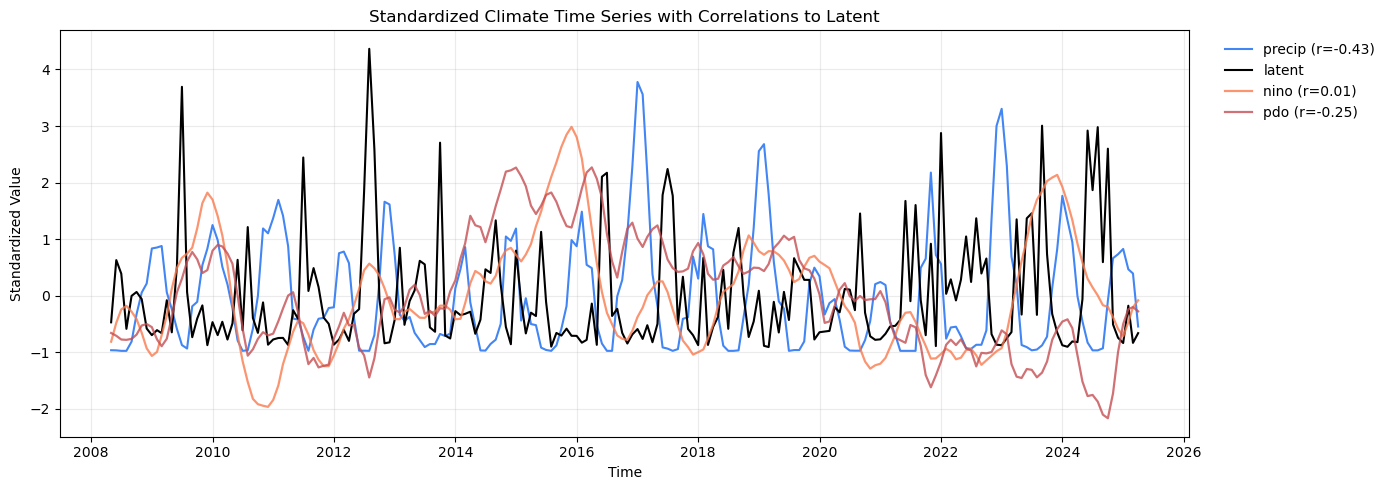

In [43]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.figure(figsize=(14,5))

dfp = aligned.copy()

# Z-score for comparability
def z(x): return (x - x.mean()) / x.std()

t = dfp["time_norm"]
latent = dfp["latent"]

# Compute r-values versus latent
r_precip = pearsonr(dfp["precip"], latent)[0]
r_nino   = pearsonr(dfp["nino"],   latent)[0]
r_pdo    = pearsonr(dfp["pdo"],    latent)[0]
r_ae3    = pearsonr(dfp["ae3"],    latent)[0]

# ============================
# Plot each series individually
# ============================

# PRECIP
plt.plot(
    t, z(dfp["precip"]),
    color="#4285f4cc",
    linewidth=1.5,
    alpha=1,
    label=f"precip (r={r_precip:.2f})"
)

# LATENT (reference series)
plt.plot(
    t, z(latent),
    color="black",
    linewidth=1.5,
    alpha=1,
    label="latent"
)

# NINO
plt.plot(
    t, z(dfp["nino"]),
    color="#fa7a4ddb",
    linewidth=1.6,
    alpha=0.8,
    label=f"nino (r={r_nino:.2f})"
)

# PDO
plt.plot(
    t, z(dfp["pdo"]),
    color="#C44E52",
    linewidth=1.6,
    alpha=0.8,
    label=f"pdo (r={r_pdo:.2f})"
)


'''
# AE3
plt.plot(
    t, z(dfp["ae3"]),
    color="#8172B2",
    linewidth=1.3,
    alpha=0.9,
    label=f"ae3 (r={r_ae3:.2f})"
)
'''

# ============================
# Final formatting
# ============================
plt.title("Standardized Climate Time Series with Correlations to Latent")
plt.xlabel("Time")
plt.ylabel("Standardized Value")
plt.grid(alpha=0.25)
plt.legend(loc="upper left", bbox_to_anchor=(1.02,1), frameon=False)
plt.tight_layout()
plt.show()


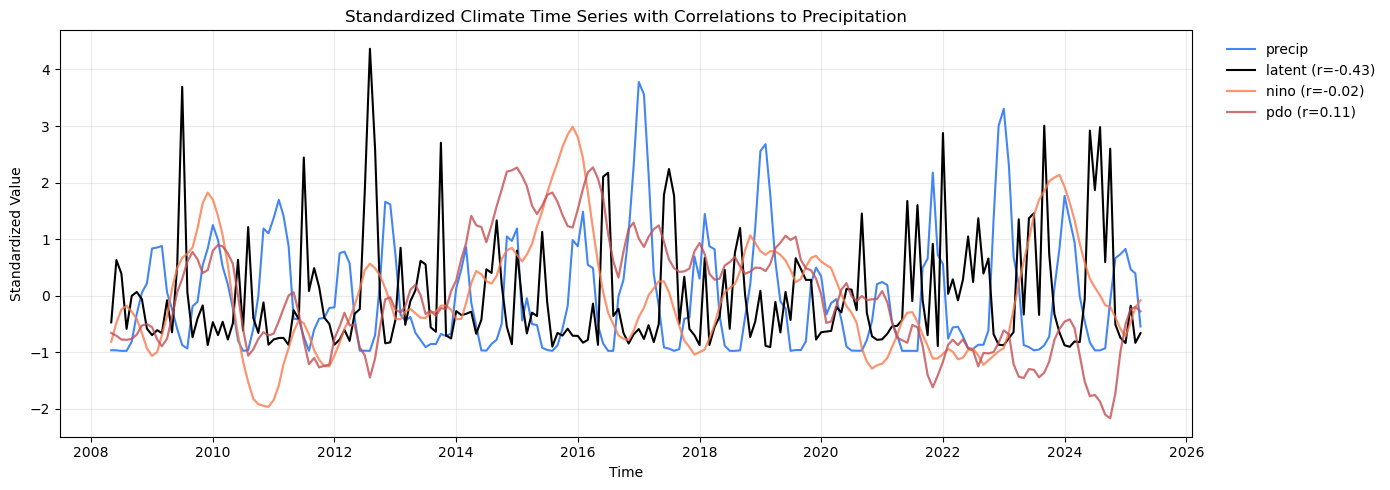

In [44]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.figure(figsize=(14,5))

dfp = aligned.copy()

# Z-score for comparability
def z(x): 
    return (x - x.mean()) / x.std()

t = dfp["time_norm"]
precip = dfp["precip"]      # ← new reference series

# ========================================
# Compute r-values versus PRECIP instead of latent
# ========================================
r_latent = pearsonr(dfp["latent"], precip)[0]
r_nino   = pearsonr(dfp["nino"],   precip)[0]
r_pdo    = pearsonr(dfp["pdo"],    precip)[0]
r_ae3    = pearsonr(dfp["ae3"],    precip)[0]

# ============================
# Plot each series individually
# ============================

# PRECIP (reference)
plt.plot(
    t, z(precip),
    color="#4285f4cc",
    linewidth=1.5,
    alpha=1,
    label=f"precip"
)

# LATENT
plt.plot(
    t, z(dfp["latent"]),
    color="black",
    linewidth=1.5,
    alpha=1,
    label=f"latent (r={r_latent:.2f})"
)

# NINO
plt.plot(
    t, z(dfp["nino"]),
    color="#fa7a4ddb",
    linewidth=1.6,
    alpha=0.8,
    label=f"nino (r={r_nino:.2f})"
)

# PDO
plt.plot(
    t, z(dfp["pdo"]),
    color="#C44E52",
    linewidth=1.6,
    alpha=0.8,
    label=f"pdo (r={r_pdo:.2f})"
)

'''
# AE3
plt.plot(
    t, z(dfp["ae3"]),
    color="#8172B2",
    linewidth=1.3,
    alpha=0.9,
    label=f"ae3 (r={r_ae3:.2f})"
)
'''

# ============================
# Final formatting
# ============================
plt.title("Standardized Climate Time Series with Correlations to Precipitation")
plt.xlabel("Time")
plt.ylabel("Standardized Value")
plt.grid(alpha=0.25)
plt.legend(loc="upper left", bbox_to_anchor=(1.02,1), frameon=False)
plt.tight_layout()
plt.show()


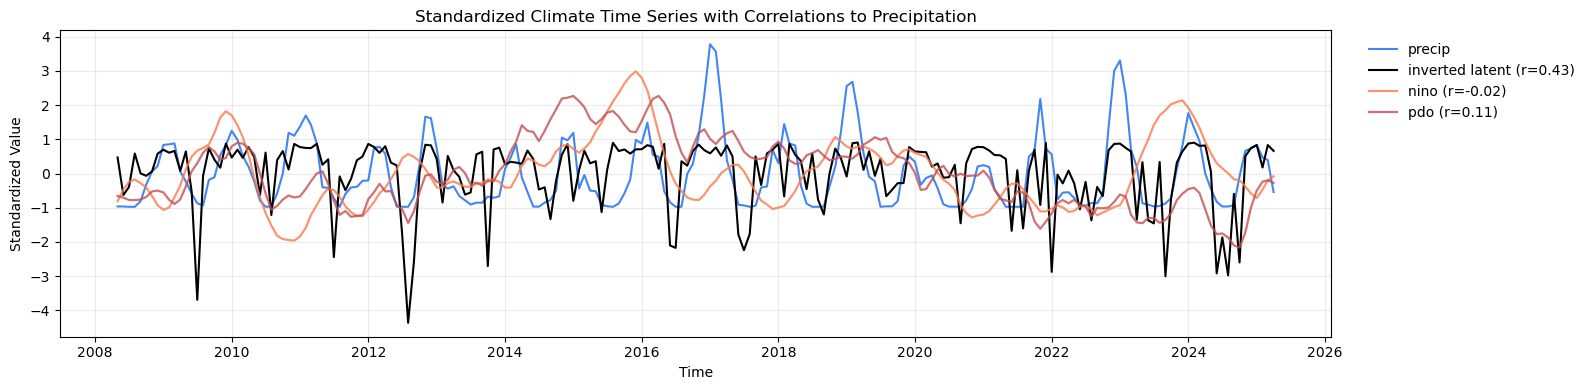

In [47]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.figure(figsize=(16,4))

dfp = aligned.copy()

# Z-score for comparability
def z(x): 
    return (x - x.mean()) / x.std()

t = dfp["time_norm"]
precip = dfp["precip"]       # reference series

# =====================================================
# INVERT LATENT INDEX (multiply by -1)
# =====================================================
dfp["latent_inv"] = -1 * dfp["latent"]

# =====================================================
# Compute r-values versus PRECIP (using inverted latent)
# =====================================================
r_latent = pearsonr(dfp["latent_inv"], precip)[0]
r_nino   = pearsonr(dfp["nino"],        precip)[0]
r_pdo    = pearsonr(dfp["pdo"],         precip)[0]
r_ae3    = pearsonr(dfp["ae3"],         precip)[0]

# ============================
# Plot each series individually
# ============================

# PRECIP (reference)
plt.plot(
    t, z(precip),
    color="#4285f4cc",
    linewidth=1.5,
    alpha=1,
    label=f"precip"
)

# LATENT (inverted)
plt.plot(
    t, z(dfp["latent_inv"]),
    color="black",
    linewidth=1.5,
    alpha=1,
    label=f"inverted latent (r={r_latent:.2f})"
)

# NINO
plt.plot(
    t, z(dfp["nino"]),
    color="#fa7a4ddb",
    linewidth=1.6,
    alpha=0.8,
    label=f"nino (r={r_nino:.2f})"
)

# PDO
plt.plot(
    t, z(dfp["pdo"]),
    color="#C44E52",
    linewidth=1.6,
    alpha=0.8,
    label=f"pdo (r={r_pdo:.2f})"
)

'''
# AE3
plt.plot(
    t, z(dfp["ae3"]),
    color="#8172B2",
    linewidth=1.3,
    alpha=0.9,
    label=f"ae3 (r={r_ae3:.2f})"
)
'''

# ============================
# Final formatting
# ============================
plt.title("Standardized Climate Time Series with Correlations to Precipitation")
plt.xlabel("Time")
plt.ylabel("Standardized Value")
plt.grid(alpha=0.25)
plt.legend(loc="upper left", bbox_to_anchor=(1.02,1), frameon=False)
plt.tight_layout()
plt.show()


In [67]:
import pandas as pd

# -------------------------
# Load monthly climate data
# -------------------------
ninoy    = pd.read_csv('~/signal-extraction/vae_input_data/psl_nino34_index_clean.csv')
pdoy     = pd.read_csv('~/signal-extraction/vae_input_data/ncei_pdo_index.csv')
mimoaey  = pd.read_csv('~/signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv')
latenty  = pd.read_csv("~/signal-extraction/results/gam_gnll_s1r2/gam_gnlls1r2_extractr_results_latent_full.csv")
precipy  = pd.read_csv("~/signal-extraction/vae_input_data/GHCND_Sac_5ESE_monsum.csv")

# -------------------------
# Clean column names
# -------------------------
ninoy = ninoy.rename(columns={'DATE':'time', 'INDEX':'nino'})
pdoy  = pdoy.rename(columns={'Date':'time', 'value':'pdo'})

latenty = latenty.drop(columns=['alpha','beta','lambda'], errors='ignore')

# -------------------------
# Standardize monthly timestamps
# -------------------------
ninoy['time']    = pd.to_datetime(ninoy['time'])
pdoy['time']     = pd.to_datetime(pdoy['time'])
mimoaey['time']  = pd.to_datetime(mimoaey["time"])
latenty['time']  = pd.to_datetime(latenty["time"])
precipy['time']  = pd.to_datetime(precipy["time"])

# -------------------------
# OPTIONAL: remove rolling averages (you requested annual aggregation instead)
# -------------------------
# So we skip the 12-month rolling smoothing
# and go directly to annual means.

# -------------------------
# Annual aggregation helper
# -------------------------
def annual_mean(df, time_col, val_col, newname):
    df = df[[time_col, val_col]].set_index(time_col)
    ann = df[val_col].resample("YE").max()
    ann.index = ann.index.year          # convert "YYYY-12-31" to YYYY
    return ann.reset_index().rename(columns={val_col: newname})

# -------------------------
# Compute annual means
# -------------------------
nino_ann   = annual_mean(ninoy,   "time", "nino",   "nino")
pdo_ann    = annual_mean(pdoy,    "time", "pdo",    "pdo")
ae3_ann    = annual_mean(mimoaey, "time", "latent", "ae3")
latent_ann = annual_mean(latenty, "time", "latent", "latent")
precip_ann = annual_mean(precipy, "time", "PRCP",   "precip")

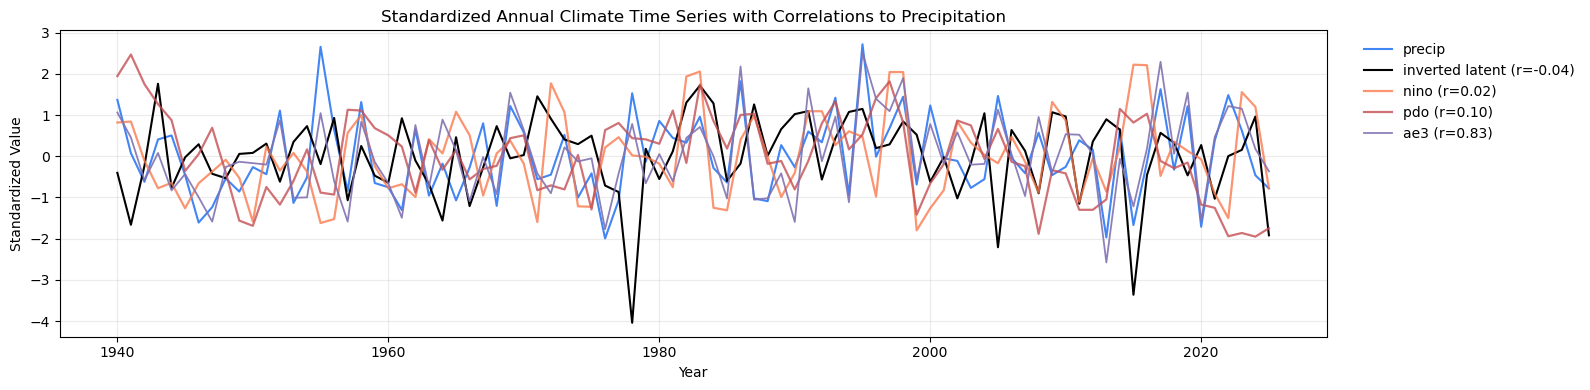

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ======================================================
# STEP 1 — Align all annual series internally
# ======================================================

# Start with precipitation (reference)
aligned = precip_ann.copy()

# Merge others by 'time'
aligned = aligned.merge(latent_ann, on="time", how="inner")
aligned = aligned.merge(nino_ann,   on="time", how="inner")
aligned = aligned.merge(pdo_ann,    on="time", how="inner")
aligned = aligned.merge(ae3_ann,    on="time", how="inner")

# Drop any rows with missing values
aligned = aligned.dropna()

# Now aligned has columns:
# time, precip, latent, nino, pdo, ae3


# ======================================================
# STEP 2 — Z-score function
# ======================================================
def z(x):
    return (x - x.mean()) / x.std()


# ======================================================
# STEP 3 — Invert latent and compute correlations
# ======================================================

aligned["latent_inv"] = -1 * aligned["latent"]

# r-values vs precipitation
r_latent = pearsonr(aligned["latent_inv"], aligned["precip"])[0]
r_nino   = pearsonr(aligned["nino"],       aligned["precip"])[0]
r_pdo    = pearsonr(aligned["pdo"],        aligned["precip"])[0]
r_ae3    = pearsonr(aligned["ae3"],        aligned["precip"])[0]

t = aligned["time"]   # annual axis


# ======================================================
# STEP 4 — Plotting
# ======================================================

plt.figure(figsize=(16,4))

# PRECIP
plt.plot(
    t, z(aligned["precip"]),
    color="#4285f4cc",
    linewidth=1.5,
    alpha=1,
    label="precip"
)

# LATENT (inverted)
plt.plot(
    t, z(aligned["latent_inv"]),
    color="black",
    linewidth=1.5,
    alpha=1,
    label=f"inverted latent (r={r_latent:.2f})"
)

# NINO
plt.plot(
    t, z(aligned["nino"]),
    color="#fa7a4ddb",
    linewidth=1.6,
    alpha=0.8,
    label=f"nino (r={r_nino:.2f})"
)

# PDO
plt.plot(
    t, z(aligned["pdo"]),
    color="#C44E52",
    linewidth=1.6,
    alpha=0.8,
    label=f"pdo (r={r_pdo:.2f})"
)

# AE3
plt.plot(
    t, z(aligned["ae3"]),
    color="#8172B2",
    linewidth=1.3,
    alpha=0.9,
    label=f"ae3 (r={r_ae3:.2f})"
)

# ======================================================
# Final formatting
# ======================================================
plt.title("Standardized Annual Climate Time Series with Correlations to Precipitation")
plt.xlabel("Year")
plt.ylabel("Standardized Value")
plt.grid(alpha=0.25)
plt.legend(loc="upper left", bbox_to_anchor=(1.02,1), frameon=False)
plt.tight_layout()
plt.show()


In [69]:
import pandas as pd

# -------------------------
# Load monthly climate data
# -------------------------
ninoy    = pd.read_csv('~/signal-extraction/vae_input_data/psl_nino34_index_clean.csv')
pdoy     = pd.read_csv('~/signal-extraction/vae_input_data/ncei_pdo_index.csv')
mimoaey  = pd.read_csv('~/signal-extraction/results/MIMOAE/mon_mean_sst-mon_sum_tp-mm.csv')
latenty  = pd.read_csv("~/signal-extraction/results/gam_gnll_s1r2/gam_gnlls1r2_extractr_results_latent_full.csv")
precipy  = pd.read_csv("~/signal-extraction/vae_input_data/GHCND_Sac_5ESE_monsum.csv")

# -------------------------
# Clean column names
# -------------------------
ninoy = ninoy.rename(columns={'DATE':'time', 'INDEX':'nino'})
pdoy  = pdoy.rename(columns={'Date':'time', 'value':'pdo'})
latenty = latenty.drop(columns=['alpha','beta','lambda'], errors='ignore')

# -------------------------
# Convert timestamps
# -------------------------
ninoy['time']    = pd.to_datetime(ninoy['time'])
pdoy['time']     = pd.to_datetime(pdoy['time'])
mimoaey['time']  = pd.to_datetime(mimoaey["time"])
latenty['time']  = pd.to_datetime(latenty["time"])
precipy['time']  = pd.to_datetime(precipy["time"])

# -------------------------
# Apply 12-month smoothing
# -------------------------
window = 12

ninoy['nino_12']   = ninoy['nino'].rolling(window=window, center=True).mean()
pdoy['pdo_12']     = pdoy['pdo'].rolling(window=window, center=True).mean()
mimoaey['ae3_12']  = mimoaey['latent'].rolling(window=window, center=True).mean()
latenty['latent_12'] = latenty['latent'].rolling(window=window, center=True).mean()
precipy['precip_12'] = precipy['PRCP'].rolling(window=window, center=True).mean()


# Slide 3

In [140]:
series = pd.read_csv('~/signal-extraction/results/gam_gnll_s1r2/gam_gnlls1r2_extractr_results_latent_full.csv')

alpha = series['alpha']
beta = series['beta']
gammaz = series['latent']
gammatime = series['time']

In [148]:
print(series.head())

                  time    latent     alpha      beta    lambda
0  1940-01-16 00:00:00  0.082685  1.204500  9.708056  0.124072
1  1940-02-15 00:00:00  0.089934  1.190729  9.805576  0.121434
2  1940-03-16 00:00:00  0.483903  1.245523  9.422826  0.132181
3  1940-04-15 12:00:00  0.656417  1.654649  5.005506  0.330566
4  1940-05-16 00:00:00  1.001494  1.701316  3.476045  0.489440


In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_z_with_shading_monthly_df(df,
                                   time_col="time",
                                   z_col="latent",
                                   alpha_col="alpha",
                                   beta_col="beta",
                                   title_prefix="MIMOVAE"):
    """
    Plot latent z(t) with Gamma-derived uncertainty band on a clean monthly axis.

    df must contain:
        time_col  : datetime-like column
        z_col     : latent sample
        alpha_col : Gamma shape
        beta_col  : Gamma rate
    """

    # --- Ensure proper datetime in the time column ---
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="raise")

    # --- Collapse to monthly means using a PeriodIndex ---
    df["month"] = df[time_col].dt.to_period("M")
    monthly = (
        df.groupby("month")[[z_col, alpha_col, beta_col]]
          .mean()
          .reset_index()
    )

    # Convert Period to Timestamp for plotting (month start)
    monthly["tstamp"] = monthly["month"].dt.to_timestamp()

    # --- Compute μ and σ from alpha, beta ---
    mu  = monthly[alpha_col] / monthly[beta_col]
    std = np.sqrt(monthly[alpha_col]) / monthly[beta_col]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(14, 5))

    # z(t)
    ax.plot(
        monthly["tstamp"],
        monthly[z_col],
        color="black",
        linewidth=1.4,
        label="z(t)"
    )

    # Shading: μ ± σ
    ax.fill_between(
        monthly["tstamp"],
        (mu - std),
        (mu + std),
        alpha=0.28,
        color="gray",
        label="μ ± σ"
    )

    # --- Time axis formatting: tick every 5 years ---
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))   # ticks every 5 years
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # --- Labels and style ---
    ax.set_title(f"{title_prefix} Latent Index", fontsize = 14)
    ax.set_ylabel("Latent Index", fontsize = 14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    plt.tight_layout()
    
    plt.show()


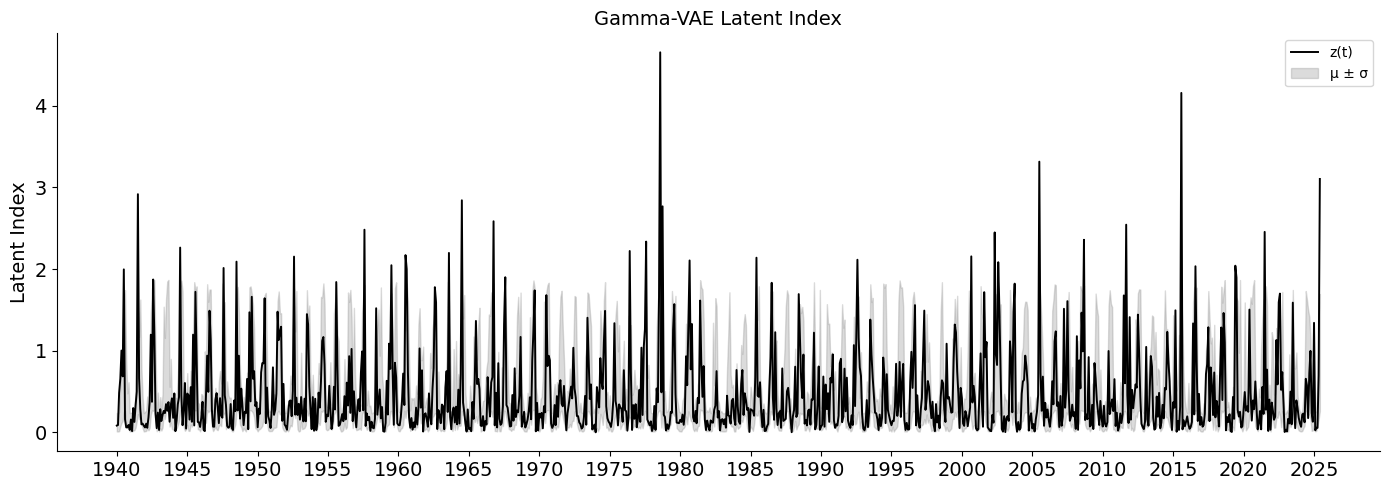

In [175]:
plot_z_with_shading_monthly_df(series, 'time', 'latent', 'alpha', 'beta', 'Gamma-VAE')

# KDEs

In [234]:
kde_gam = pd.read_csv("~/signal-extraction/results/gam_gnll_s1r2/gam_gnlls1r2_extractr_results_latent_full.csv")
kde_ae = pd.read_csv('~/signal-extraction/results/mimoae_base/mimoae_base_extractr_results_latent.csv')
kde_ae['ln'] = kde_ae['latent']*(-1)
kde_discharge = pd.read_csv('~/signal-extraction/vae_input_data/AR_cfs.csv')

In [252]:
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def plot_three_kdes(
    a, b, c,
    labels=None,
    title="KDE Comparison",
    standardize=True,
    colors=None,
    alphas=None
):
    """
    Plot three overlaid *filled* KDEs from Series, DataArray, ndarray, or list.

    Parameters
    ----------
    a, b, c : data variables
        Each may be pandas Series, xarray.DataArray, numpy array, or list.
    labels : list of str, optional
    title : str
    standardize : bool
        Independently z-score each variable before KDE.
    colors : list of str (hex or named colors)
        Colors for each KDE curve.
    alphas : list of float
        Opacities (0–1) for each KDE fill.
    """

    # Helper to convert to 1-D numpy array
    def to_array(x):
        if isinstance(x, pd.Series):
            return x.dropna().to_numpy().astype(float)
        elif isinstance(x, xr.DataArray):
            return np.asarray(x.values).flatten().astype(float)
        elif isinstance(x, (np.ndarray, list, tuple)):
            return np.asarray(x).flatten().astype(float)
        else:
            raise TypeError(
                f"Unsupported type {type(x)}. Expected Series, DataArray, ndarray, or list."
            )

    # Extract arrays
    data0 = to_array(a)
    data1 = to_array(b)
    data2 = to_array(c)

    # Standardize
    def zscore(x):
        mu = np.nanmean(x)
        sigma = np.nanstd(x)
        return (x - mu) / sigma if sigma > 0 else x * 0.0

    if standardize:
        data0 = zscore(data0)
        data1 = zscore(data1)
        data2 = zscore(data2)

    # Labels
    if labels is None:
        labels = ["Dist A", "Dist B", "Dist C"]

    # Colors
    if colors is None:
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # seaborn defaults
    if alphas is None:
        alphas = [0.35, 0.35, 0.35]

    # Plot
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(12, 8))

    sns.kdeplot(data0, label=labels[0], linewidth=2,
                color=colors[0], fill=True, alpha=alphas[0], ax=ax)
    sns.kdeplot(data1, label=labels[1], linewidth=2,
                color=colors[1], fill=True, alpha=alphas[1], ax=ax)
    sns.kdeplot(data2, label=labels[2], linewidth=2,
                color=colors[2], fill=True, alpha=alphas[2], ax=ax)

    # Remove top & right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Standardized Value (z-score)" if standardize else "Mon. Sum Precipitation (m)", fontsize = 20)
    ax.set_ylabel("Density", fontsize=20)
    ax.legend(fontsize = 18)

    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    plt.tight_layout()
    plt.show()


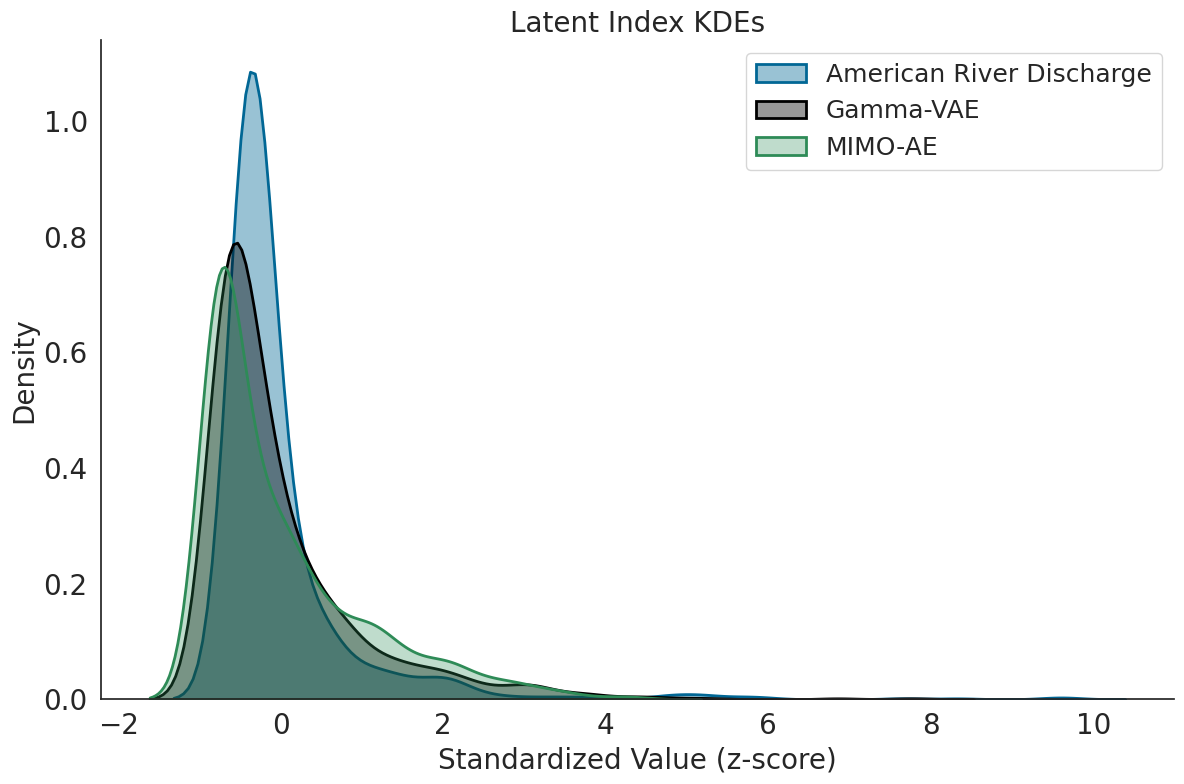

In [250]:
plot_three_kdes(
    kde_discharge['cfs'],
    kde_gam['latent'],
    kde_ae['ln'],
    labels=["American River Discharge", "Gamma-VAE", "MIMO-AE"],
    title="Latent Index KDEs",
    colors=["xkcd:peacock blue","black", "seagreen"],
    alphas=[0.4, 0.4, 0.3]
)

In [236]:
gam_tp = xr.open_dataset('~/signal-extraction/results/gam_gnll_s1r2/gam_gnlls1r2_extractr_results_precip.nc')
ae_tp = xr.open_dataset('~/signal-extraction/results/mimoae_base/mimoae_base_extractr_results_precip.nc')
obs_tp = xr.open_dataset('~/signal-extraction/vae_input_data/tp_mon-sum.nc')

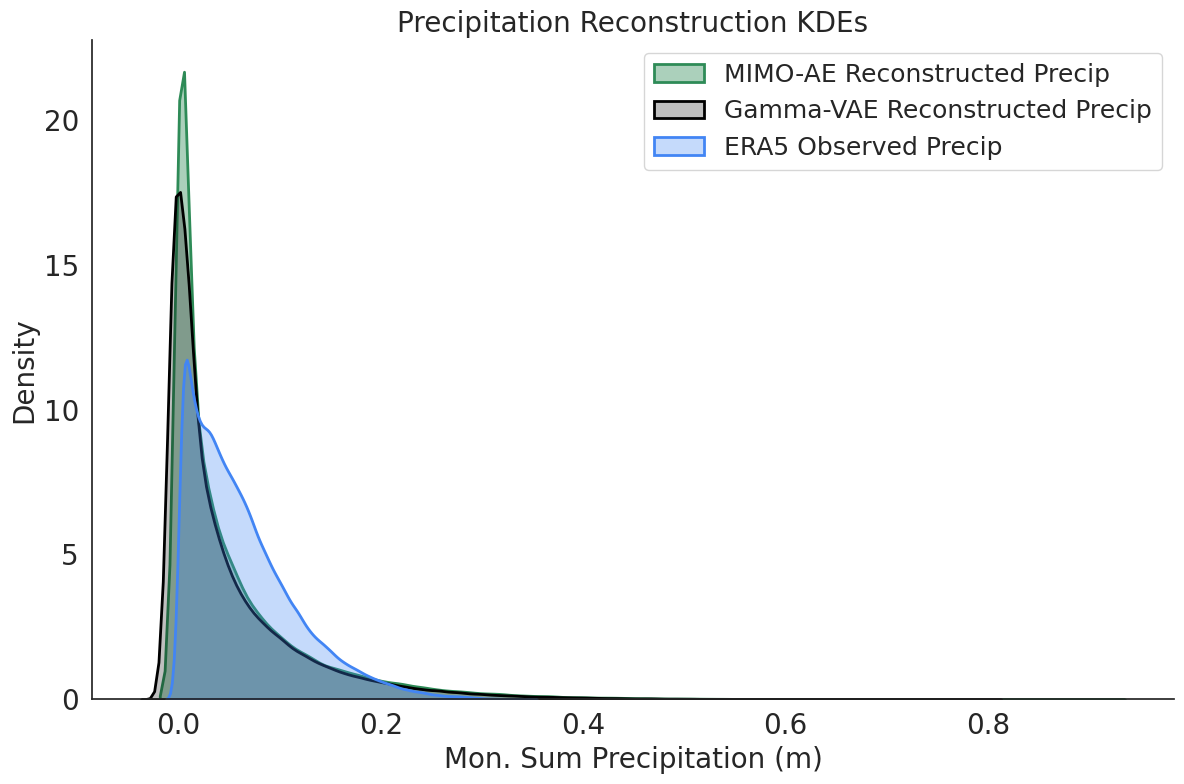

In [253]:
plot_three_kdes(
    obs_tp['tp'],
    ae_tp['precip'],
    gam_tp['precip'],
    labels=["MIMO-AE Reconstructed Precip", "Gamma-VAE Reconstructed Precip", "ERA5 Observed Precip",],
    standardize =False,
    title="Precipitation Reconstruction KDEs",
    colors=["seagreen","black","#4285f4cc"],
    alphas=[0.4, 0.25, 0.3]
)

# Wavelet

In [254]:
from simulator_code.Wavelet import *

In [284]:
wave_precip = pd.read_csv('~/signal-extraction/vae_input_data/GHCND_Sac_5ESE_clean.csv')

In [310]:
annual_max_df = annual_max_df.reset_index()

In [311]:
wave_discharge = annual_max_df.copy()

In [312]:
wave_discharge

,datetime,annual_max_streamflow
0,1904-12-31,11600.0
1,1905-12-31,21200.0
2,1906-12-31,44500.0
3,1907-12-31,105000.0
4,1908-12-31,7030.0
...,...,...
117,2021-12-31,5050.0
118,2022-12-31,9760.0
119,2023-12-31,32500.0
120,2024-12-31,6360.0


In [313]:
# Load
signal = wave_discharge

# --- Choose which latent variable to process ---
latent_var = 'annual_max_streamflow'   # or "lambda", "alpha", "beta", etc.
time_var = 'datetime'

# Ensure datetime index (and sorted)
signal[time_var] = pd.to_datetime(signal[time_var], errors='coerce')
signal = signal.set_index(time_var).sort_index()

# Make sure latent_var column is numeric
signal[latent_var] = pd.to_numeric(signal[latent_var], errors='coerce')

# --- Shift to ensure positivity ---
latent_min = signal[latent_var].min()
if latent_min <= 0:
    eps = 1e-6  # nominal epsilon for numerical stability
    shift_value = -latent_min + eps
    signal[latent_var] = signal[latent_var] + shift_value
    print(f"Shifted '{latent_var}' upward by {shift_value:.6f} to ensure positivity.")

# Signal date window
sig_start = signal.index.min()
sig_end   = signal.index.max()

# Annual means of the latent variable
latent_annual_max = signal[latent_var].resample('YE').mean()

# Years (from the index, not the values)
latent_years = signal.index.year
latent_time = np.unique(latent_years)

# Series of annual mean values
latent_time_series = latent_annual_max.values


In [314]:
siglvl_wave = 0.95
sigtest = 'default'

In [315]:
# wavelet transform
#warnings.filterwarnings('ignore', 'divide by zero encountered in divide', RuntimeWarning)
wlt = wavelet(latent_time_series)
Cw = CI(wlt, latent_time_series, siglvl_wave, "r")
C = CI(wlt, latent_time_series, siglvl_wave, "w")

# Global Wavelet Spectrum
plt_dataset = {
    'Time': latent_time,
    'Period': wlt['period'],
    'Avg_Power': wlt['avg_power'],
    'Power': wlt['power'],
    'COI': wlt['coi'],
    'W_noise': C['sig'],
    'R_noise': Cw['sig']
}

Red Noise AR1 Coefficient: 0.5744193589065603


/home/jovyan/signal-extraction/simulator_code/Wavelet.py:50: RuntimeWarning: divide by zero encountered in divide
  expnt = -(scl * k - param) ** 2 / (2 * (k > 0))


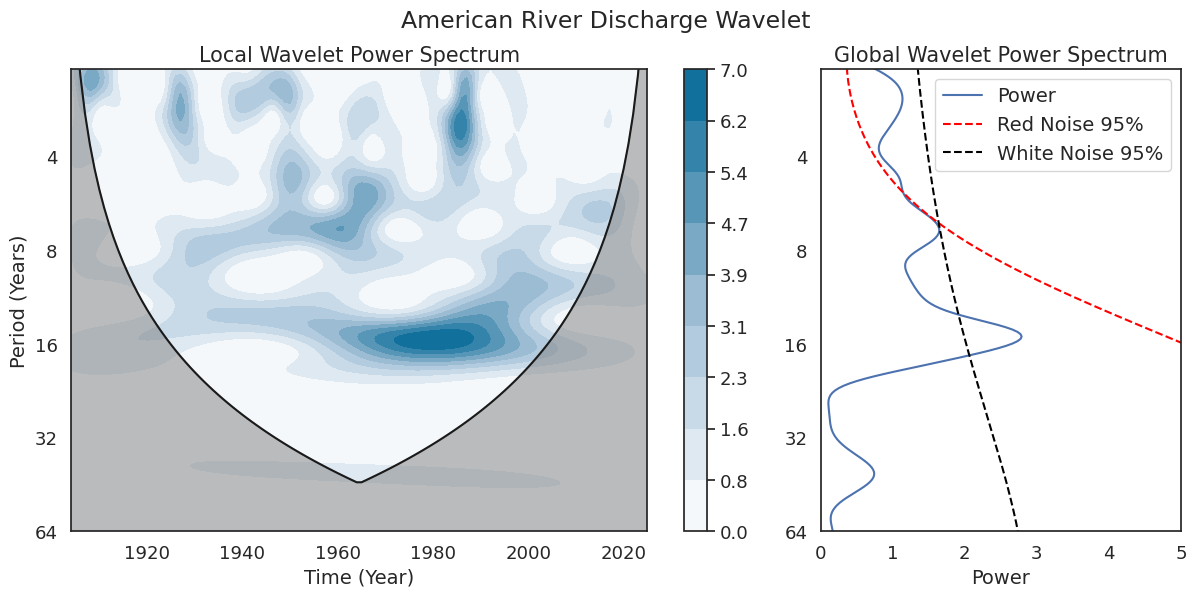

In [316]:
wavelet_plot(plt_dataset, siglvl_wave, 'American River Discharge', sigtest,'xkcd:light grey blue', 'xkcd:peacock blue')

# Last Part

In [319]:
tpview_coords = xr.open_dataset('~/signal-extraction/vae_input_data/tp_mon-sum.nc')
sstview_coords = xr.open_dataset('~/signal-extraction/vae_input_data/sst_mon-mean.nc')


In [324]:
print(f"Precip: (lon max:{tpview_coords['longitude'].max()}, lon min:{tpview_coords['longitude'].min()} \n lat max:{tpview_coords['latitude'].max()}, lat min:{tpview_coords['latitude'].min()}")

Precip: (lon max:<xarray.DataArray 'longitude' ()> Size: 8B
array(-119.), lon min:<xarray.DataArray 'longitude' ()> Size: 8B
array(-123.) 
 lat max:<xarray.DataArray 'latitude' ()> Size: 8B
array(40.), lat min:<xarray.DataArray 'latitude' ()> Size: 8B
array(36.)


In [325]:
print(f"SST: (lon max:{sstview_coords['longitude'].max()}, lon min:{sstview_coords['longitude'].min()} \n lat max:{sstview_coords['latitude'].max()}, lat min:{sstview_coords['latitude'].min()}")

SST: (lon max:<xarray.DataArray 'longitude' ()> Size: 8B
array(-120.), lon min:<xarray.DataArray 'longitude' ()> Size: 8B
array(-170.) 
 lat max:<xarray.DataArray 'latitude' ()> Size: 8B
array(5.), lat min:<xarray.DataArray 'latitude' ()> Size: 8B
array(-5.)


In [390]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_precip_bbox():
    lon_min, lon_max = -123, -119
    lat_min, lat_max = 36, 40

    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(10, 4), subplot_kw={"projection": proj})

    # Set map extent slightly larger than ROI
    ax.set_extent([lon_min - 5, lon_max + 5,
                   lat_min - 5, lat_max + 5], crs=proj)

    # Base features
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.7)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle= '--',color="gray", alpha=0.5)
    gl.right_labels = False
    gl.top_labels = False

    # Bounding box rectangle
    rect = patches.Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=2,
        edgecolor='black',
        facecolor='#4285f4cc',
        alpha=0.4,
        transform=proj
    )
    ax.add_patch(rect)

    #ax.set_title("Precipitation Region", fontsize=16)
    plt.show()


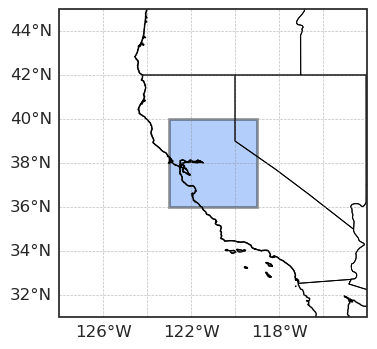

In [391]:
plot_precip_bbox()

In [413]:
def plot_sst_bbox():
    lon_min, lon_max = -170, -120
    lat_min, lat_max = -5, 5

    proj = ccrs.PlateCarree(central_longitude=180)
    fig, ax = plt.subplots(figsize=(10, 4), subplot_kw={"projection": proj})

    # Wider window for context
    ax.set_extent([150, 290, -30, 30], crs=ccrs.PlateCarree())
    
    # Base features
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
  #  ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.7)

    import matplotlib.ticker as mticker
    
    gl = ax.gridlines(draw_labels=True,
                      linewidth=0.5,
                      linestyle='--',
                      color="gray",
                      alpha=0.5)
    
    # SIMPLEST POSSIBLE FIX: force longitude lines every 10 degrees
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 10))
    
    gl.right_labels = False
    gl.top_labels = False


    '''    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle= '--',color="gray", alpha=0.5)
    gl.right_labels = False
    gl.top_labels = False

    '''
    # Bounding box
    rect = patches.Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=2,
        edgecolor='black',
        facecolor='#fa7a4ddb',
        alpha=0.6,
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)

   # ax.set_title("SST Region (with State Borders)", fontsize=16)
    plt.show()


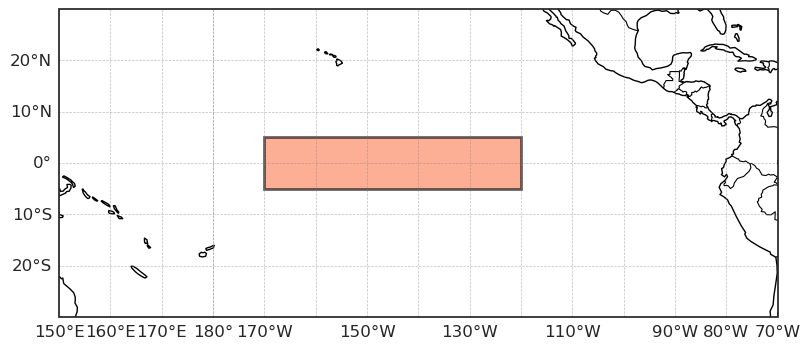

In [414]:
plot_sst_bbox()